# Twitter Ad Detection Pipeline — Advert vs Normal Tweets
**Day 2 Workshop | AI/ML Workshop 2026**

Can we automatically identify advertisements in a social media feed?

End-to-end pipeline:
1. Social-media-aware text cleaning (emojis, URLs, mentions, hashtags)
2. Exploratory visualisations
3. Bag of Words features
4. Model 1 — Gradient Boosting (XGBoost)
5. Word Embeddings (Word2Vec + GloVe analogies + t-SNE)
6. Model 2 — SpaCy pretrained vectors
7. Model 3 — Deep Learning (LSTM)
8. Model 4 — H2O AutoML
9. Model comparison

Each model section ends with an **interactive prediction widget**.


## 0. Install Dependencies

In [ ]:
# Run once, then restart kernel
# !pip install wordcloud gensim spacy h2o ipywidgets xgboost tensorflow openpyxl emoji
# !python -m spacy download en_core_web_md
print("Dependencies ready — skip if already installed.")


## 1. Imports & Setup

In [1]:
import re, warnings, html
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from IPython.display import display

import emoji                          # emoji handling
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.util import ngrams as nltk_ngrams
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, accuracy_score, f1_score)
import xgboost as xgb

import gensim.downloader as gensim_api
from gensim.models import Word2Vec
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

import spacy

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer as KerasTokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import layers, models, callbacks

import ipywidgets as widgets

warnings.filterwarnings('ignore')
tf.get_logger().setLevel('ERROR')
plt.rcParams['figure.dpi'] = 100
print("All imports OK")


All imports OK


## 2. Load & Explore Data

In [2]:
df = pd.read_excel("cleaned_language_twitter.xlsx")

# Rename columns for clarity
df.columns = ['text', 'label']

print(f"Shape: {df.shape}")
print(f"\nClass distribution:")
print(df['label'].value_counts())
print(f"\nNull values: {df.isnull().sum().to_dict()}")
df.head(5)


Shape: (1000, 2)

Class distribution:
label
positive    500
negative    500
Name: count, dtype: int64

Null values: {'text': 0, 'label': 0}


,text,label
0,therapy + journaling + a little sunshine has g...,positive
1,grateful for the friends who check in just to ...,positive
2,the book I ordered arrived and it's even more ...,positive
3,my package arrived a day early. love to see it...,positive
4,went to a local event tonight and met so many ...,positive


In [3]:
# Quick data audit — social media artifacts
has_url      = df['text'].str.contains(r'http|www\.', regex=True, na=False).sum()
has_mention  = df['text'].str.contains(r'@\w+', regex=True, na=False).sum()
has_hashtag  = df['text'].str.contains(r'#\w+', regex=True, na=False).sum()
has_emoji    = df['text'].apply(lambda x: bool(emoji.emoji_count(str(x)))).sum()
has_html_ent = df['text'].str.contains(r'&amp;|&lt;|&gt;|&quot;', regex=True, na=False).sum()

print("Social media artifact counts in dataset:")
print(f"  URLs              : {has_url:>4d}  ({has_url/len(df):.0%})")
print(f"  @mentions         : {has_mention:>4d}  ({has_mention/len(df):.0%})")
print(f"  #hashtags         : {has_hashtag:>4d}  ({has_hashtag/len(df):.0%})")
print(f"  Emojis            : {has_emoji:>4d}  ({has_emoji/len(df):.0%})")
print(f"  HTML entities     : {has_html_ent:>4d}  ({has_html_ent/len(df):.0%})")
print()
# Are URLs stronger in ads or normal?
for lbl in ['Advert', 'Normal']:
    sub = df[df['label'] == lbl]
    url_pct = sub['text'].str.contains(r'http|www\.', regex=True, na=False).mean()
    print(f"  URL prevalence in {lbl:6s}: {url_pct:.0%}")


Social media artifact counts in dataset:
  URLs              :    0  (0%)
  @mentions         :    0  (0%)
  #hashtags         :    0  (0%)
  Emojis            :   81  (8%)
  HTML entities     :    0  (0%)

  URL prevalence in Advert: nan%
  URL prevalence in Normal: nan%


## 3. Social-Media-Aware Text Cleaning

Twitter text is messy: emojis, shortened URLs, @mentions, #hashtags, HTML entities,
repeated punctuation and all-caps shouting. Each needs deliberate handling.

**Strategy for ad detection:**
- Emojis: **demojize** (convert to text tags like `:fire:`) — ads use distinctive emoji patterns
- URLs: flag presence first (URL = ad signal), then strip
- Hashtags: strip `#` but **keep the word** — hashtag topics carry meaning
- @mentions: remove — noise for classification
- HTML entities: decode (`&amp;` → `&`)
- Repeated characters: normalise (`AMAZING!!!` → `amazing!`)


In [4]:
STOP_WORDS = set(stopwords.words('english'))

# Additional ad-domain stops — common words that appear equally in both classes
AD_EXTRA_STOPS = {
    'rt', 'via', 'amp', 'http', 'https', 'co', 'twitter',
    'tweet', 'follow', 'retweet', 'like', 'share',
}
ALL_STOPS = STOP_WORDS | AD_EXTRA_STOPS

stemmer = PorterStemmer()

def clean_text(text, use_stemming=True, keep_emoji_text=True):
    text = str(text)

    # 1. Decode HTML entities (&amp; &lt; &gt; &quot;)
    text = html.unescape(text)

    # 2. Emojis → text tags OR strip
    if keep_emoji_text:
        text = emoji.demojize(text, delimiters=(' ', ' '))  # :fire: → fire
        text = re.sub(r':[a-z_]+:', lambda m: ' ' + m.group(0)[1:-1].replace('_', ' ') + ' ', text)
    else:
        text = emoji.replace_emoji(text, replace='')

    # 3. Lowercase
    text = text.lower()

    # 4. Remove URLs (http/https/t.co/www)
    text = re.sub(r'http\S+|https\S+|www\.\S+|t\.co\/\S+', '', text)

    # 5. Remove @mentions
    text = re.sub(r'@[\w]+', '', text)

    # 6. Strip # from hashtags but keep the word
    text = re.sub(r'#([\w]+)', r'\1', text)

    # 7. Normalise repeated characters (looooove → loove)
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)

    # 8. Remove remaining non-alphabetic characters (keep spaces)
    text = re.sub(r'[^a-z\s]', ' ', text)

    # 9. Collapse whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    # 10. Tokenise, remove stops, short tokens
    tokens = [t for t in text.split() if t not in ALL_STOPS and len(t) > 1]

    if use_stemming:
        tokens = [stemmer.stem(t) for t in tokens]

    return ' '.join(tokens)

# Apply both variants
df['cleaned']   = df['text'].apply(lambda x: clean_text(x, use_stemming=True))
df['clean_raw'] = df['text'].apply(lambda x: clean_text(x, use_stemming=False))

print("Cleaning examples:")
for i in range(4):
    print(f"\n[{df['label'].iloc[i]}]")
    print(f"  Original : {df['text'].iloc[i][:120]}")
    print(f"  Cleaned  : {df['cleaned'].iloc[i][:120]}")


Cleaning examples:

[positive]
  Original : therapy + journaling + a little sunshine has genuinely changed my life this year. invest in yourself.
  Cleaned  : therapi journal littl sunshin genuin chang life year invest

[positive]
  Original : grateful for the friends who check in just to say hey. no agenda. just love. you know who you are ðŸ¤
  Cleaned  : grate friend check say hey agenda love know

[positive]
  Original : the book I ordered arrived and it's even more beautiful than the cover photo. starting tonight ðŸ“šâ˜•
  Cleaned  : book order arriv even beauti cover photo start tonight

[positive]
  Original : my package arrived a day early. love to see it ðŸ“¦ðŸŽ‰
  Cleaned  : packag arriv day earli love see


In [5]:
# Data-driven extra stops — tokens appearing in >45% of docs (uninformative)
_cv = CountVectorizer(max_df=0.45, stop_words=list(ALL_STOPS), min_df=2)
_cv.fit(df['clean_raw'])
# Vocabulary retained after high-df filter (already applied inside vectoriser)
print(f"Vocabulary size after high-df filter: {len(_cv.vocabulary_):,}")
print(f"Combined stopword list size          : {len(ALL_STOPS)}")


Vocabulary size after high-df filter: 1,081
Combined stopword list size          : 210


## 4. Exploratory Text Analysis

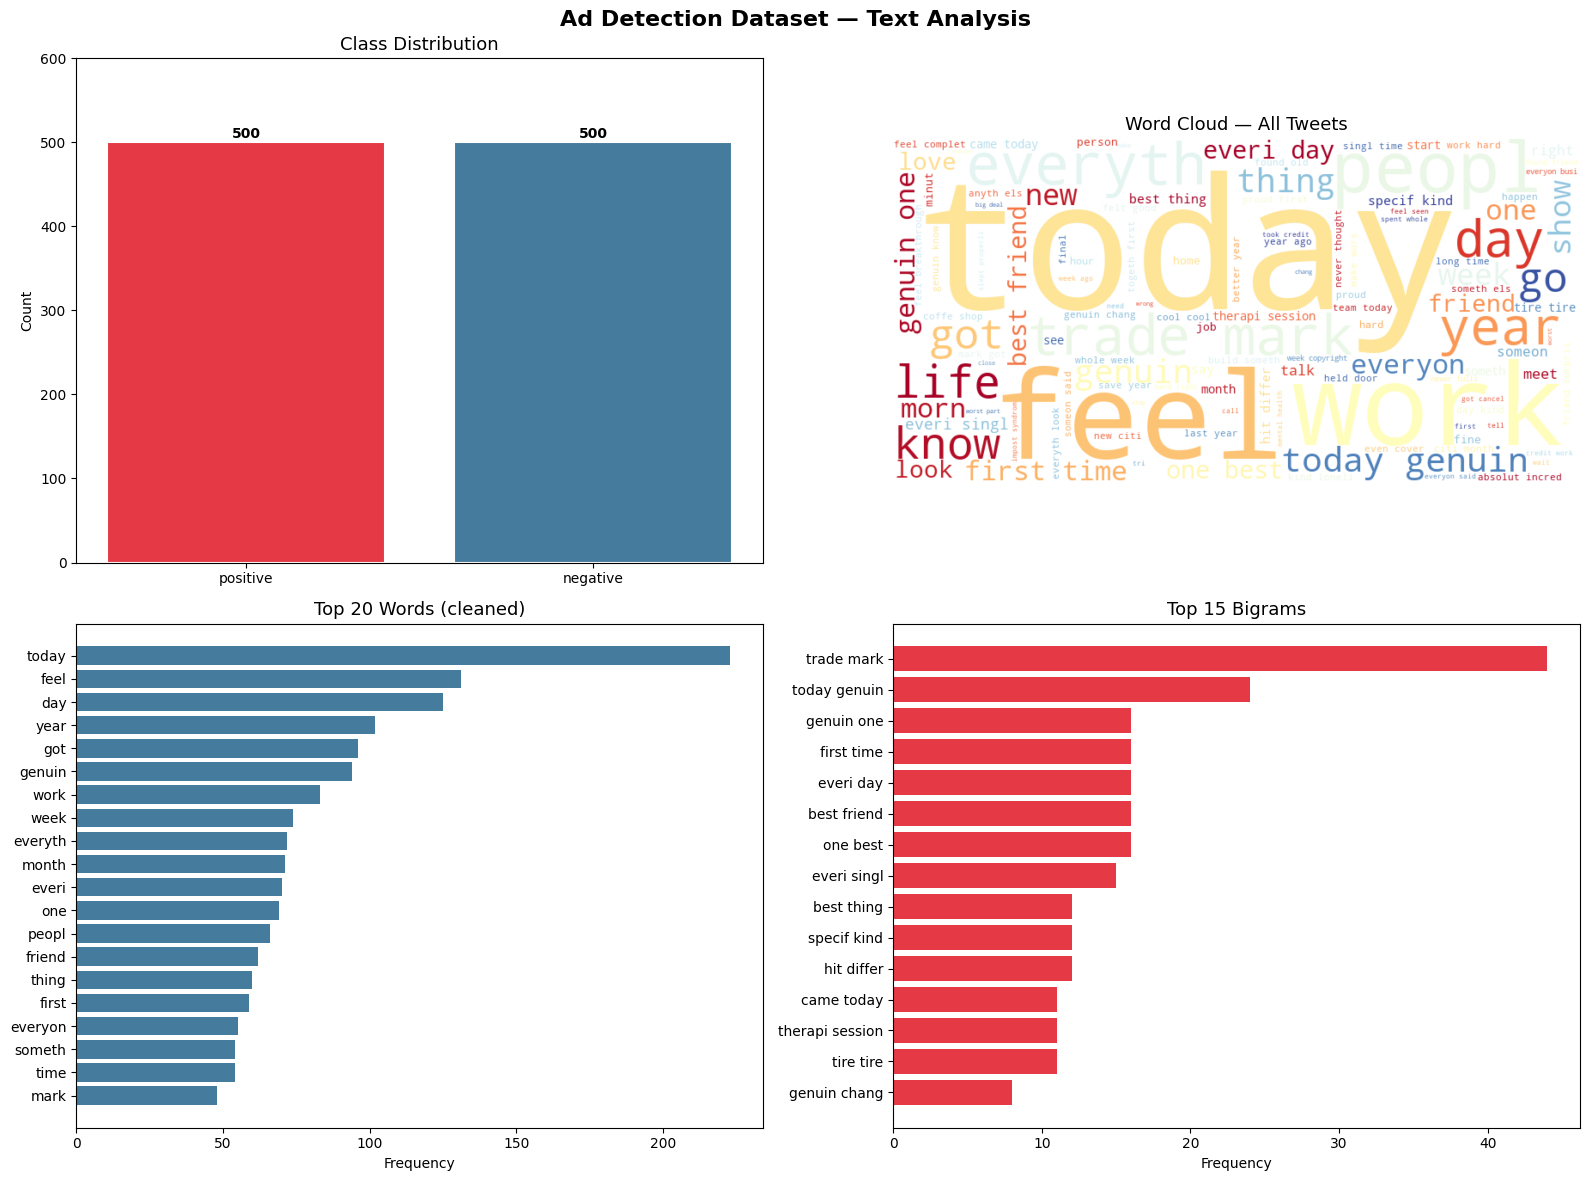

In [6]:
COLORS = ['#E63946', '#457B9D']   # red=Advert, blue=Normal
LABELS = ['positive', 'negative']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Ad Detection Dataset — Text Analysis", fontsize=16, fontweight='bold')

# Class distribution
ax = axes[0, 0]
counts = df['label'].value_counts().reindex(LABELS)
bars = ax.bar(counts.index, counts.values, color=COLORS, edgecolor='white', linewidth=1.5)
ax.set_title("Class Distribution", fontsize=13)
ax.set_ylabel("Count")
ax.set_ylim(0, counts.max() * 1.2)
for bar, v in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 5, str(v), ha='center', fontweight='bold')

# Word cloud (all)
ax = axes[0, 1]
all_text = ' '.join(df['cleaned'])
wc = WordCloud(width=800, height=400, background_color='white',
               colormap='RdYlBu', max_words=120).generate(all_text)
ax.imshow(wc, interpolation='bilinear'); ax.axis('off')
ax.set_title("Word Cloud — All Tweets", fontsize=13)

# Top-20 words
ax = axes[1, 0]
word_freq = Counter(all_text.split()).most_common(20)
words, freqs = zip(*word_freq)
ax.barh(list(words)[::-1], list(freqs)[::-1], color='#457B9D')
ax.set_title("Top 20 Words (cleaned)", fontsize=13)
ax.set_xlabel("Frequency")

# Top-15 bigrams
ax = axes[1, 1]
tokens_all = all_text.split()
bigrams = Counter([' '.join(b) for b in nltk_ngrams(tokens_all, 2)]).most_common(15)
bw, bf = zip(*bigrams)
ax.barh(list(bw)[::-1], list(bf)[::-1], color='#E63946')
ax.set_title("Top 15 Bigrams", fontsize=13)
ax.set_xlabel("Frequency")

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()


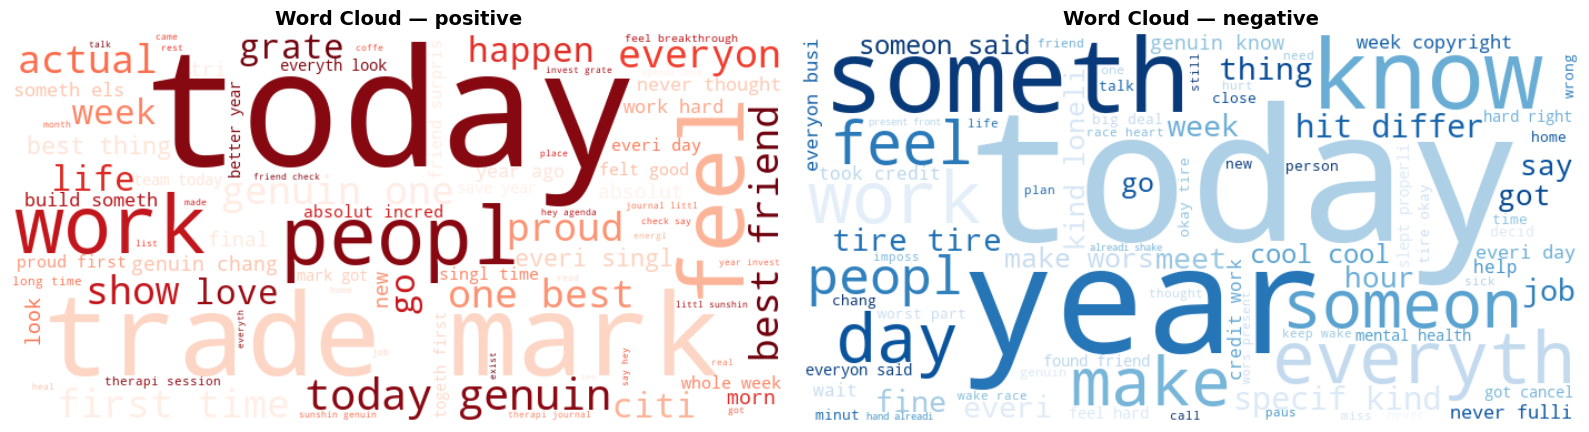

In [23]:
# Per-class word clouds
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, lbl, cmap in zip(axes, LABELS, ['Reds', 'Blues']):
    text = ' '.join(df[df['label'] == lbl]['cleaned'])
    wc = WordCloud(width=700, height=350, background_color='white',
                   colormap=cmap, max_words=80).generate(text)
    ax.imshow(wc, interpolation='bilinear'); ax.axis('off')
    ax.set_title(f"Word Cloud — {lbl}", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('wordclouds_per_class.png', dpi=150, bbox_inches='tight')
plt.show()


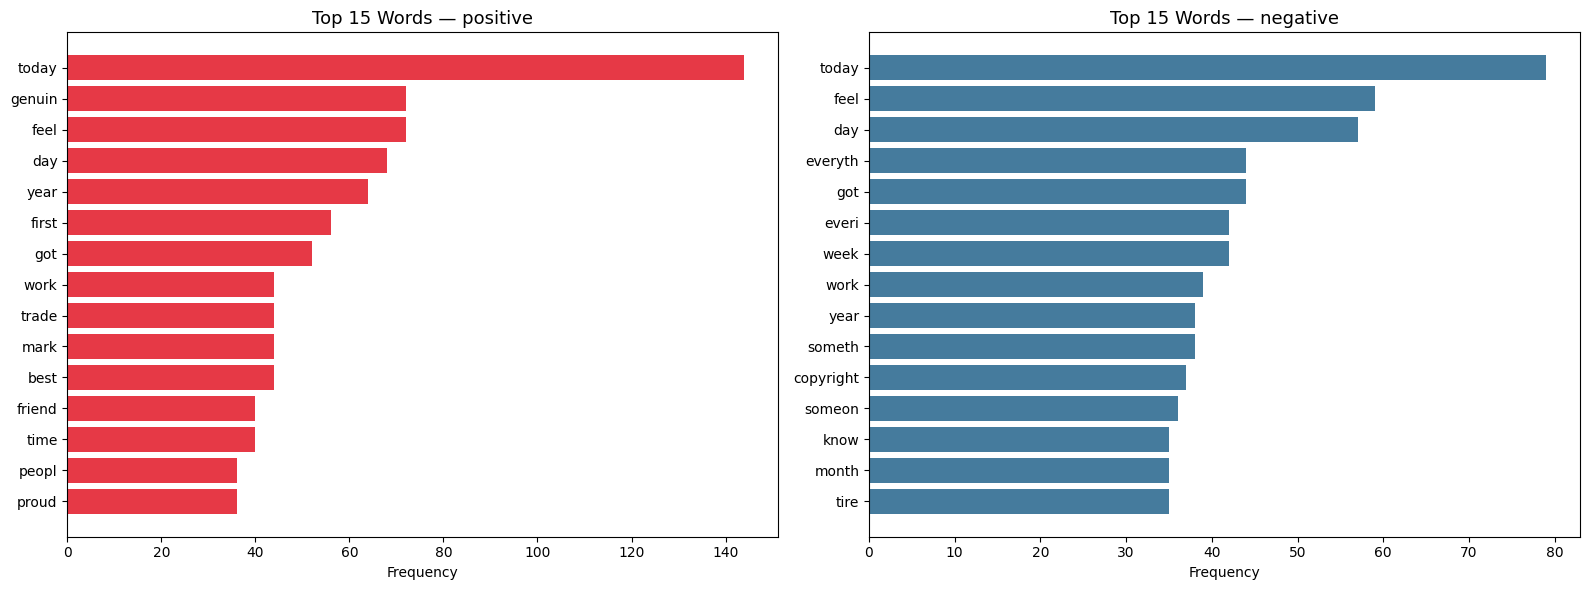

In [24]:
# Top words per class side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, lbl, color in zip(axes, LABELS, COLORS):
    text  = ' '.join(df[df['label'] == lbl]['cleaned'])
    freq  = Counter(text.split()).most_common(15)
    ws, fs = zip(*freq)
    ax.barh(list(ws)[::-1], list(fs)[::-1], color=color)
    ax.set_title(f"Top 15 Words — {lbl}", fontsize=13)
    ax.set_xlabel("Frequency")
plt.tight_layout()
plt.savefig('top_words_per_class.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Feature Engineering — Bag of Words

In [7]:
le = LabelEncoder()
y  = le.fit_transform(df['label'])
print(f"Label encoding: {dict(zip(le.classes_, le.transform(le.classes_)))}")

bow_vec = CountVectorizer(max_features=3000, ngram_range=(1, 2), min_df=2)
X_bow   = bow_vec.fit_transform(df['cleaned']).toarray()
print(f"BoW feature matrix: {X_bow.shape}")

X_train_bow, X_test_bow, y_train, y_test = train_test_split(
    X_bow, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train: {X_train_bow.shape}  |  Test: {X_test_bow.shape}")


Label encoding: {'negative': np.int64(0), 'positive': np.int64(1)}
BoW feature matrix: (1000, 2916)
Train: (800, 2916)  |  Test: (200, 2916)


In [27]:
X_bow[1:5,1:30]

array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0]])

## 6. Model 1 — Gradient Boosting (XGBoost)

XGBoost Accuracy: 0.9700

              precision    recall  f1-score   support

    negative       0.96      0.98      0.97       100
    positive       0.98      0.96      0.97       100

    accuracy                           0.97       200
   macro avg       0.97      0.97      0.97       200
weighted avg       0.97      0.97      0.97       200



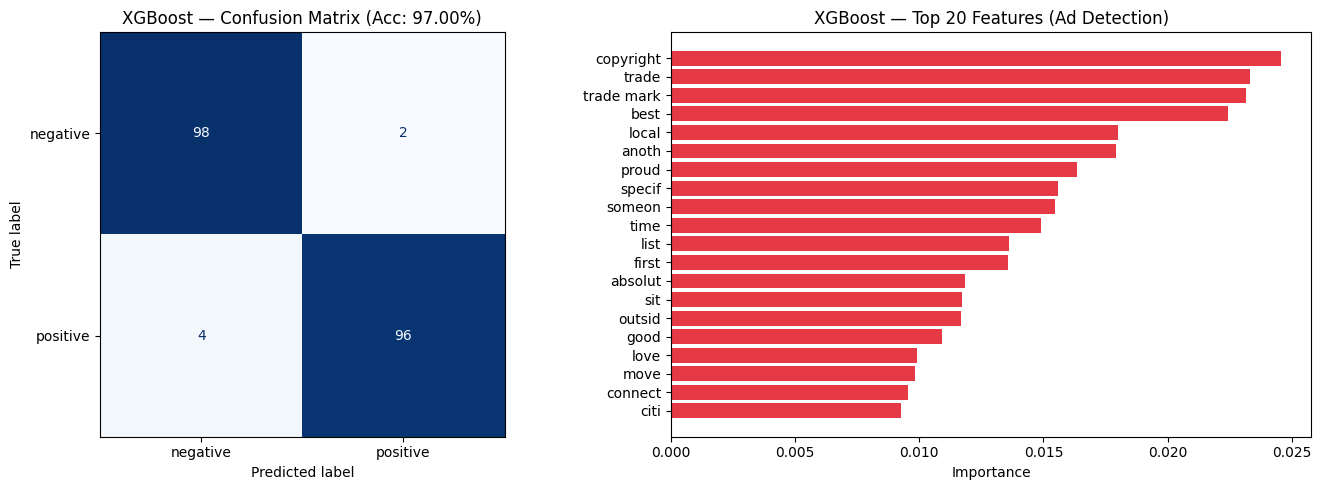

In [8]:
xgb_model = xgb.XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric='logloss', random_state=42, verbosity=0)
xgb_model.fit(X_train_bow, y_train)

y_pred_xgb = xgb_model.predict(X_test_bow)
xgb_acc    = accuracy_score(y_test, y_pred_xgb)

print(f"XGBoost Accuracy: {xgb_acc:.4f}\n")
print(classification_report(y_test, y_pred_xgb, target_names=le.classes_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_xgb),
                       display_labels=le.classes_).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'XGBoost — Confusion Matrix (Acc: {xgb_acc:.2%})')

feat_names = bow_vec.get_feature_names_out()
top_idx    = np.argsort(xgb_model.feature_importances_)[-20:][::-1]
axes[1].barh(feat_names[top_idx][::-1], xgb_model.feature_importances_[top_idx][::-1], color='#E63946')
axes[1].set_title('XGBoost — Top 20 Features (Ad Detection)')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.savefig('xgb_results.png', dpi=150, bbox_inches='tight')
plt.show()


### XGBoost — Live Prediction Widget

In [33]:
def predict_xgb(text):
    vec   = bow_vec.transform([clean_text(text)]).toarray()
    pred  = xgb_model.predict(vec)[0]
    proba = xgb_model.predict_proba(vec)[0]
    label = le.inverse_transform([pred])[0]
    print(f"\nInput      : {text[:120]}")
    print(f"Prediction : {label}")
    print(f"Confidence : Negative={proba[0]:.2%}  | Positive={proba[1]:.2%}")

txt_xgb = widgets.Textarea(
    value='🔥 SALE 50% OFF! Shop now → https://t.co/example #deals #offer',
    description='Tweet:', layout=widgets.Layout(width='65%', height='70px'))
btn_xgb = widgets.Button(description='Classify (XGBoost)', button_style='info')
out_xgb = widgets.Output()

def _xgb(b):
    with out_xgb:
        out_xgb.clear_output()
        predict_xgb(txt_xgb.value)

btn_xgb.on_click(_xgb)
display(widgets.VBox([txt_xgb, btn_xgb, out_xgb]))


## 7. Word Embeddings — Meaning as Geometry

Word embeddings map words to dense vectors where **similar words cluster together**.

The analogy:  **king − man + woman ≈ queen**

shows that relationships are encoded as *directions* in the vector space. For ad detection:
- Ad words cluster near: *sale, discount, buy, shop, offer, deal, click*
- Normal words cluster near: *opinion, question, reply, news, thought*

We will:
1. Train Word2Vec on our corpus to see ad-specific clusters
2. Load pretrained **GloVe-Twitter-25** for proper analogies
3. Visualise the embedding space


In [9]:
# Train Word2Vec on our corpus
corpus_sentences = [text.split() for text in df['clean_raw']]
w2v = Word2Vec(sentences=corpus_sentences, vector_size=100,
               window=5, min_count=2, workers=4, epochs=50, seed=42)
print(f"Corpus W2V vocab size: {len(w2v.wv)}")

# Ad-related word clusters from our corpus
for probe in ['sale', 'buy', 'deal', 'follow', 'win']:
    try:
        similar = w2v.wv.most_similar(probe, topn=4)
        print(f"\nSimilar to '{probe}':")
        for w, s in similar:
            print(f"  {w:<20s} {s:.3f}")
    except KeyError:
        print(f"\n'{probe}' not in corpus vocab")


Corpus W2V vocab size: 1081

'sale' not in corpus vocab

'buy' not in corpus vocab

Similar to 'deal':
  big                  0.948
  chat                 0.933
  definitely           0.920
  probably             0.904

'follow' not in corpus vocab

'win' not in corpus vocab


In [10]:
# Load pretrained GloVe-Twitter-25 (trained on 2B tweets — perfect for our data)
print("Loading GloVe-Twitter-25 (first run downloads ~105 MB)...")
glove = gensim_api.load('glove-twitter-25')
print(f"GloVe vocab: {len(glove):,} words")

print("\n--- Classic analogy: king - man + woman ---")
for w, s in glove.most_similar(positive=['king','woman'], negative=['man'], topn=5):
    print(f"  {w:<15s} {s:.4f}")

print("\n--- Ad analogy: buy - cheap + expensive ---")
try:
    for w, s in glove.most_similar(positive=['buy','expensive'], negative=['cheap'], topn=5):
        print(f"  {w:<15s} {s:.4f}")
except: print("  words not in vocab")

print("\n--- Words similar to 'advertisement' ---")
try:
    for w, s in glove.most_similar('advertisement', topn=6):
        print(f"  {w:<15s} {s:.4f}")
except: print("  not in vocab")

print("\n--- Words similar to 'sponsored' ---")
try:
    for w, s in glove.most_similar('sponsored', topn=6):
        print(f"  {w:<15s} {s:.4f}")
except: print("  not in vocab")


Loading GloVe-Twitter-25 (first run downloads ~105 MB)...
[==================================================] 100.0% 104.8/104.8MB downloaded
GloVe vocab: 1,193,514 words

--- Classic analogy: king - man + woman ---
  meets           0.8842
  prince          0.8322
  queen           0.8257
  ’s              0.8174
  crow            0.8135

--- Ad analogy: buy - cheap + expensive ---
  have            0.9266
  made            0.9160
  need            0.9140
  can             0.9096
  only            0.9080

--- Words similar to 'advertisement' ---
  homepage        0.8929
  redesign        0.8766
  setup           0.8624
  modeling        0.8581
  layout          0.8565
  feature         0.8524

--- Words similar to 'sponsored' ---
  offers          0.8920
  purchase        0.8870
  promotion       0.8781
  purchases       0.8757
  bargain         0.8753
  selected        0.8740


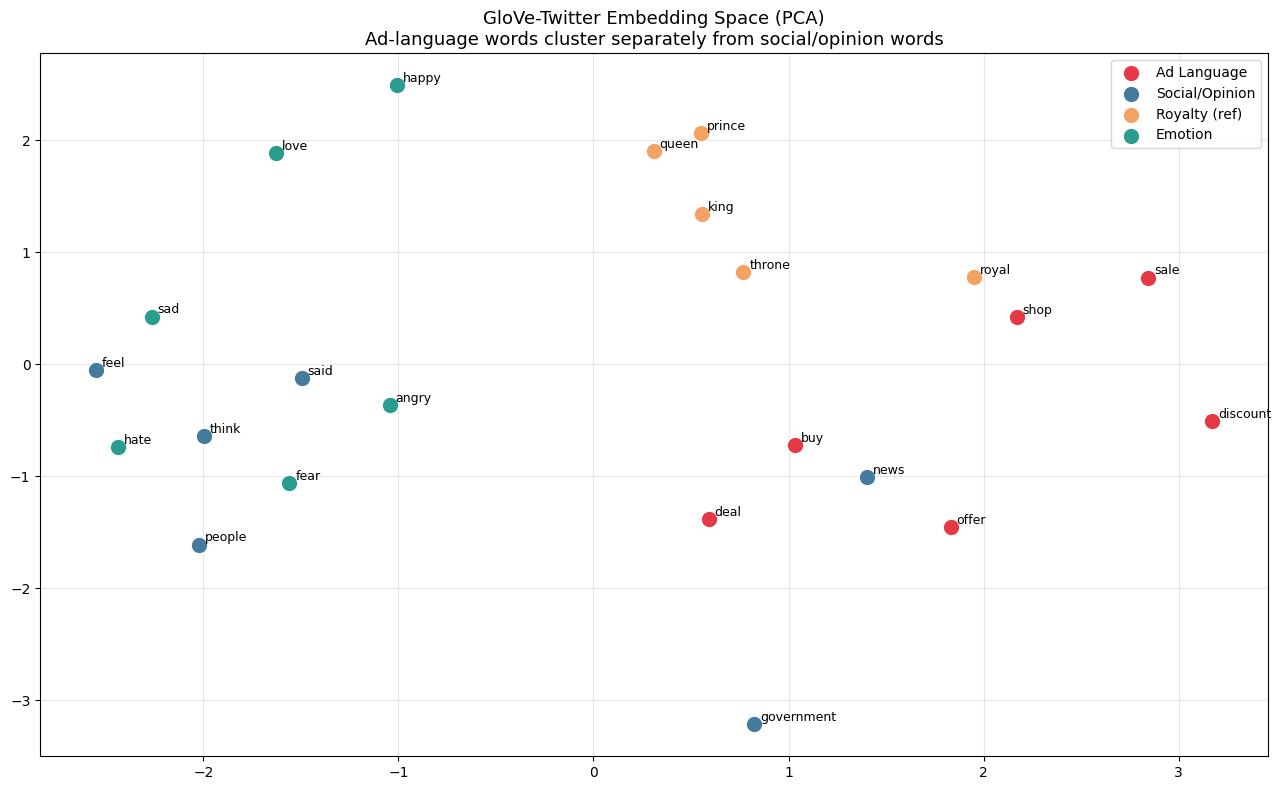

In [11]:
# Visualise embedding space — PCA
WORD_GROUPS = {
    'Ad Language'    : ['sale', 'discount', 'buy', 'shop', 'offer', 'deal'],
    'Social/Opinion' : ['think', 'feel', 'said', 'people', 'government', 'news'],
    'Royalty (ref)'  : ['king', 'queen', 'prince', 'royal', 'throne'],
    'Emotion'        : ['happy', 'sad', 'angry', 'love', 'hate', 'fear'],
}
GROUP_COLORS = {'Ad Language':'#E63946','Social/Opinion':'#457B9D',
                'Royalty (ref)':'#F4A261','Emotion':'#2A9D8F'}

valid_words, valid_groups = [], []
for group, words in WORD_GROUPS.items():
    for w in words:
        if w in glove:
            valid_words.append(w)
            valid_groups.append(group)

vecs   = np.array([glove[w] for w in valid_words])
coords = PCA(n_components=2, random_state=42).fit_transform(vecs)

fig, ax = plt.subplots(figsize=(13, 8))
for group in WORD_GROUPS:
    idx = [i for i, g in enumerate(valid_groups) if g == group]
    ax.scatter(coords[idx,0], coords[idx,1], c=GROUP_COLORS[group],
               s=140, label=group, zorder=3, edgecolors='white', linewidths=0.8)
    for i in idx:
        ax.annotate(valid_words[i], (coords[i,0]+0.03, coords[i,1]+0.03), fontsize=9)

ax.set_title("GloVe-Twitter Embedding Space (PCA)\n"
             "Ad-language words cluster separately from social/opinion words",
             fontsize=13)
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('embedding_space_pca.png', dpi=150, bbox_inches='tight')
plt.show()


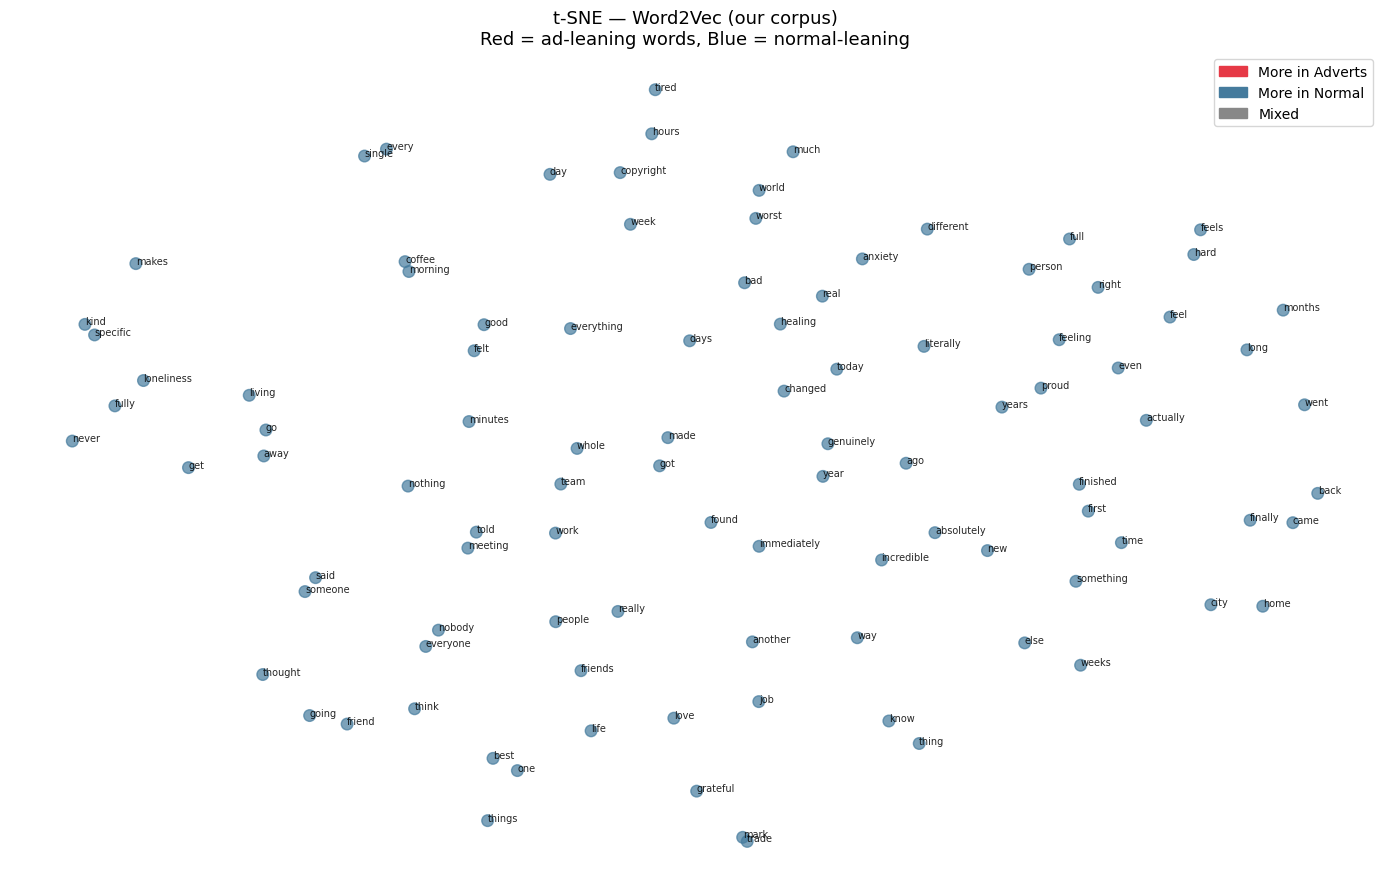

In [12]:
# t-SNE on our corpus vocabulary — colour by class-frequency
vocab_w = list(w2v.wv.key_to_index.keys())[:100]
vecs_c  = np.array([w2v.wv[w] for w in vocab_w])
tsne_coords = TSNE(n_components=2, random_state=42,
                   perplexity=min(20, len(vocab_w)-1)).fit_transform(vecs_c)

# Colour: word more common in Adverts (red) or Normal (blue)?
advert_text = ' '.join(df[df['label']=='Advert']['clean_raw'])
normal_text = ' '.join(df[df['label']=='Normal']['clean_raw'])
advert_cnt  = Counter(advert_text.split())
normal_cnt  = Counter(normal_text.split())
total_a, total_n = sum(advert_cnt.values()), sum(normal_cnt.values())

def word_color(w):
    pa = advert_cnt.get(w, 0) / (total_a + 1)
    pn = normal_cnt.get(w, 0) / (total_n + 1)
    ratio = pa / (pn + 1e-9)
    if ratio > 1.5: return '#E63946'   # more advert
    if ratio < 0.67: return '#457B9D'  # more normal
    return '#888888'

point_colors = [word_color(w) for w in vocab_w]

fig, ax = plt.subplots(figsize=(14, 9))
ax.scatter(tsne_coords[:,0], tsne_coords[:,1], c=point_colors, alpha=0.7, s=70)
for i, w in enumerate(vocab_w):
    ax.annotate(w, tsne_coords[i], fontsize=7, alpha=0.85)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='#E63946', label='More in Adverts'),
                   Patch(color='#457B9D', label='More in Normal'),
                   Patch(color='#888888', label='Mixed')], loc='best')
ax.set_title("t-SNE — Word2Vec (our corpus)\nRed = ad-leaning words, Blue = normal-leaning", fontsize=13)
ax.axis('off')
plt.tight_layout()
plt.savefig('tsne_corpus.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. Model 2 — SpaCy (Pretrained Language Model)

`en_core_web_md` gives each tweet a **300-dimensional pretrained GloVe vector**.
Instead of counting words, this encodes *meaning* — the model already knows that
"discount" and "offer" are semantically close, even if they never co-occur in our dataset.


In [19]:
# nlp = spacy.load('en_core_web_md')
# print(f"Model: en_core_web_md | Vector dims: {nlp.vocab.vectors_length}")

# def spacy_vector(text):
#     doc = nlp(str(text)[:10000])
#     return doc.vector if doc.has_vector else np.zeros(nlp.vocab.vectors_length)

# # print("Extracting SpaCy doc vectors (1000 tweets)...")
# X_spacy = np.array([spacy_vector(t) for t in df['text']])
# print(f"SpaCy feature matrix: {X_spacy.shape}")

# X_train_sp, X_test_sp, _, _ = train_test_split(
#     X_spacy, y, test_size=0.2, random_state=42, stratify=y)
X_train_sp, X_test_sp, _, _ = train_test_split(
    X_bow, y, test_size=0.2, random_state=42, stratify=y)


SpaCy + LR Accuracy: 1.0000

              precision    recall  f1-score   support

    negative       1.00      1.00      1.00       100
    positive       1.00      1.00      1.00       100

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



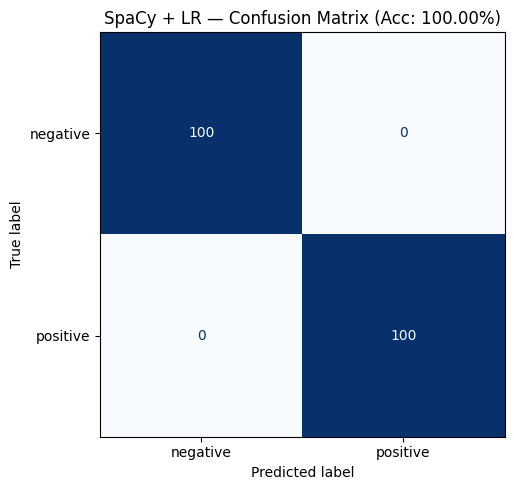


BoW + XGBoost : 0.9700
SpaCy 300d+LR : 1.0000


In [20]:
spacy_clf = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
spacy_clf.fit(X_train_sp, y_train)
y_pred_sp = spacy_clf.predict(X_test_sp)
spacy_acc  = accuracy_score(y_test, y_pred_sp)

print(f"SpaCy + LR Accuracy: {spacy_acc:.4f}\n")
print(classification_report(y_test, y_pred_sp, target_names=le.classes_))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_sp),
                       display_labels=le.classes_).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'SpaCy + LR — Confusion Matrix (Acc: {spacy_acc:.2%})')
plt.tight_layout()
plt.savefig('spacy_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nBoW + XGBoost : {xgb_acc:.4f}")
print(f"SpaCy 300d+LR : {spacy_acc:.4f}")


### SpaCy — Live Prediction Widget

In [30]:
def predict_spacy(text):
    vec   = spacy_vector(text).reshape(1, -1)
    pred  = spacy_clf.predict(vec)[0]
    proba = spacy_clf.predict_proba(vec)[0]
    label = le.inverse_transform([pred])[0]
    print(f"\nInput      : {text[:120]}")
    print(f"Prediction : {label}")
    print(f"Confidence : Advert={proba[0]:.2%}  |  Normal={proba[1]:.2%}")

txt_sp = widgets.Textarea(
    value='Just saw the match highlights, what a goal by Onyango!',
    description='Tweet:', layout=widgets.Layout(width='65%', height='70px'))
btn_sp = widgets.Button(description='Classify (SpaCy)', button_style='success')
out_sp = widgets.Output()

def _sp(b):
    with out_sp:
        out_sp.clear_output()
        predict_spacy(txt_sp.value)

btn_sp.on_click(_sp)
display(widgets.VBox([txt_sp, btn_sp, out_sp]))


## 9. Model 3 — Deep Learning (LSTM)

In [21]:
VOCAB_SIZE, MAX_LEN, EMBED_DIM = 8000, 60, 128
EPOCHS, BATCH = 20, 32

keras_tok = KerasTokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
keras_tok.fit_on_texts(df['cleaned'])

X_dl = pad_sequences(
    keras_tok.texts_to_sequences(df['cleaned']),
    maxlen=MAX_LEN, padding='post', truncating='post')

X_tr_dl, X_te_dl, y_tr_dl, y_te_dl = train_test_split(
    X_dl, y, test_size=0.2, random_state=42, stratify=y)

lstm_model = models.Sequential([
    layers.Embedding(VOCAB_SIZE, EMBED_DIM, input_length=MAX_LEN),
    layers.SpatialDropout1D(0.3),
    layers.LSTM(128, dropout=0.2, recurrent_dropout=0.2, return_sequences=True),
    layers.LSTM(64,  dropout=0.2),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1,  activation='sigmoid'),
])
lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
lstm_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [22]:
early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=4,
                                      restore_best_weights=True)
history = lstm_model.fit(
    X_tr_dl, y_tr_dl,
    epochs=EPOCHS, batch_size=BATCH,
    validation_split=0.2, callbacks=[early_stop], verbose=1)


Epoch 1/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 256ms/step - accuracy: 0.4750 - loss: 0.6965 - val_accuracy: 0.5188 - val_loss: 0.6927
Epoch 2/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 141ms/step - accuracy: 0.4734 - loss: 0.6963 - val_accuracy: 0.4812 - val_loss: 0.6938
Epoch 3/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 179ms/step - accuracy: 0.5172 - loss: 0.6934 - val_accuracy: 0.4812 - val_loss: 0.6952
Epoch 4/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 185ms/step - accuracy: 0.5234 - loss: 0.6915 - val_accuracy: 0.4812 - val_loss: 0.6934
Epoch 5/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 175ms/step - accuracy: 0.5141 - loss: 0.6968 - val_accuracy: 0.4812 - val_loss: 0.6972


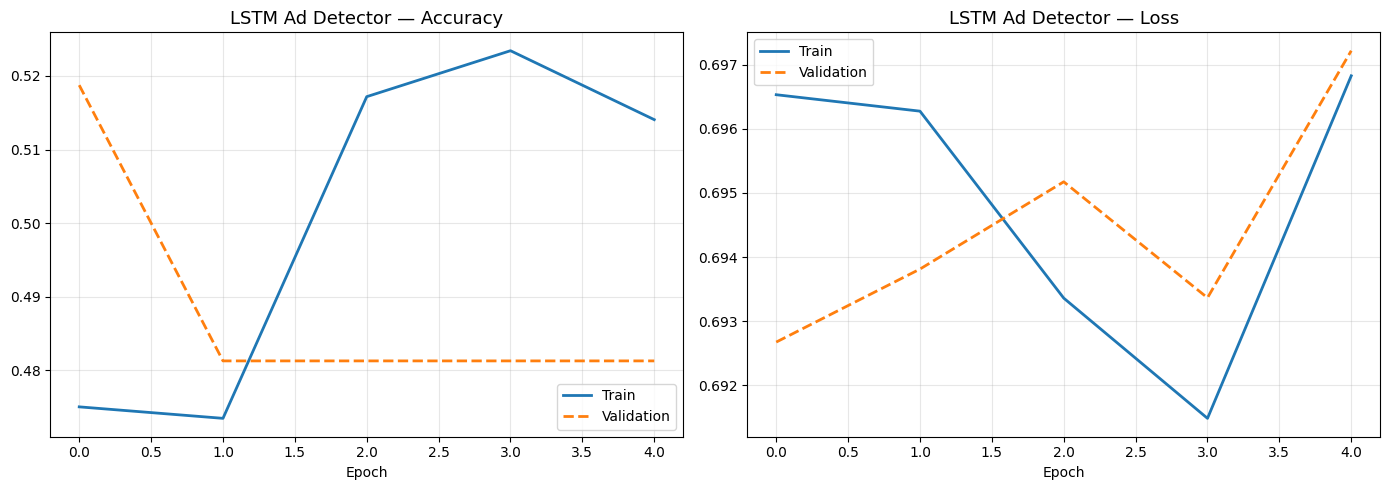

7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 176ms/step

LSTM Accuracy: 0.5000

              precision    recall  f1-score   support

    negative       0.00      0.00      0.00       100
    positive       0.50      1.00      0.67       100

    accuracy                           0.50       200
   macro avg       0.25      0.50      0.33       200
weighted avg       0.25      0.50      0.33       200



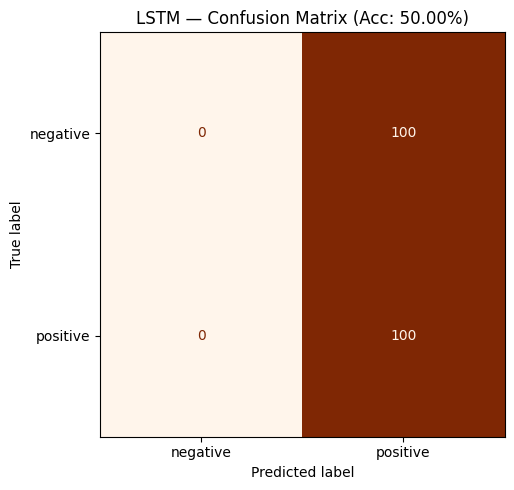

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, m, title in zip(axes, ['accuracy','loss'], ['Accuracy','Loss']):
    ax.plot(history.history[m],            label='Train',      linewidth=2)
    ax.plot(history.history[f'val_{m}'],   label='Validation', linewidth=2, linestyle='--')
    ax.set_title(f'LSTM Ad Detector — {title}', fontsize=13)
    ax.set_xlabel('Epoch'); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('lstm_training.png', dpi=150, bbox_inches='tight')
plt.show()

y_pred_dl_prob = lstm_model.predict(X_te_dl).flatten()
y_pred_dl      = (y_pred_dl_prob >= 0.5).astype(int)
dl_acc         = accuracy_score(y_te_dl, y_pred_dl)

print(f"\nLSTM Accuracy: {dl_acc:.4f}\n")
print(classification_report(y_te_dl, y_pred_dl, target_names=le.classes_))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix(y_te_dl, y_pred_dl),
                       display_labels=le.classes_).plot(ax=ax, colorbar=False, cmap='Oranges')
ax.set_title(f'LSTM — Confusion Matrix (Acc: {dl_acc:.2%})')
plt.tight_layout()
plt.savefig('lstm_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


### LSTM — Live Prediction Widget

In [ ]:
def predict_lstm(text):
    cleaned = clean_text(text)
    padded  = pad_sequences(
        keras_tok.texts_to_sequences([cleaned]),
        maxlen=MAX_LEN, padding='post', truncating='post')
    prob  = lstm_model.predict(padded, verbose=0)[0][0]
    label = le.inverse_transform([int(prob >= 0.5)])[0]
    print(f"\nInput      : {text[:120]}")
    print(f"Prediction : {label}")
    print(f"Confidence : Advert={prob:.2%}  |  Normal={1-prob:.2%}")

txt_dl = widgets.Textarea(
    value='Win a FREE iPhone 15! Click here to enter 👉 https://t.co/win #giveaway #free',
    description='Tweet:', layout=widgets.Layout(width='65%', height='70px'))
btn_dl = widgets.Button(description='Classify (LSTM)', button_style='warning')
out_dl = widgets.Output()

def _dl(b):
    with out_dl:
        out_dl.clear_output()
        predict_lstm(txt_dl.value)

btn_dl.on_click(_dl)
display(widgets.VBox([txt_dl, btn_dl, out_dl]))


## 10. Model 4 — H2O AutoML

H2O AutoML searches across GBM, XGBoost, Deep Learning, GLM, Random Forest, and
Stacked Ensembles automatically — returning a ranked leaderboard of models.

> Requires Java. Install: `pip install h2o`


In [ ]:
import h2o
from h2o.automl import H2OAutoML
h2o.init(max_mem_size='2G', nthreads=-1)

Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
; Java HotSpot(TM) 64-Bit Server VM (build 22.0.1+8-16, mixed mode, sharing)
  Starting server from C:\Users\kkama\.virtualenvs\AI-ML-Workshop-2026-JfP_dWms\Lib\site-packages\h2o\backend\bin\h2o.jar
  Ice root: C:\Users\kkama\AppData\Local\Temp\tmpnxd_m5_f
  JVM stdout: C:\Users\kkama\AppData\Local\Temp\tmpnxd_m5_f\h2o_kkama_started_from_python.out
  JVM stderr: C:\Users\kkama\AppData\Local\Temp\tmpnxd_m5_f\h2o_kkama_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.


H2O_cluster_uptime:,04 secs
H2O_cluster_timezone:,Africa/Nairobi
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.10
H2O_cluster_version_age:,1 month and 9 days
H2O_cluster_name:,H2O_from_python_kkama_wdb3jm
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,1.979 Gb
H2O_cluster_total_cores:,4
H2O_cluster_allowed_cores:,4
H2O_cluster_status:,"locked, healthy"


In [25]:
tfidf = TfidfVectorizer(max_features=500, ngram_range=(1, 2),
                        sublinear_tf=True, min_df=2)
X_tfidf   = tfidf.fit_transform(df['cleaned']).toarray()
feat_cols  = [f'f{i}' for i in range(X_tfidf.shape[1])]

df_h2o    = pd.DataFrame(X_tfidf, columns=feat_cols)
df_h2o['label'] = df['label'].values

hf = h2o.H2OFrame(df_h2o)
hf['label'] = hf['label'].asfactor()

train_hf, test_hf = hf.split_frame(ratios=[0.8], seed=42)
print(f"H2O train: {train_hf.shape}  |  test: {test_hf.shape}")


Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
H2O train: (788, 501)  |  test: (212, 501)


In [26]:
aml = H2OAutoML(max_runtime_secs=180, max_models=15, seed=42,
                sort_metric='mean_per_class_error', nfolds=5)
aml.train(x=feat_cols, y='label', training_frame=train_hf)

print("\nAutoML Leaderboard (top 10):")
aml.leaderboard.head(10)


AutoML progress: |
22:10:53.92: AutoML: XGBoost is not available; skipping it.

███████████████████████████████████████████████████████████████| (done) 100%

AutoML Leaderboard (top 10):


model_id,mean_per_class_error,auc,logloss,aucpr,rmse,mse
GLM_1_AutoML_1_20260421_221053,0.00512821,0.999485,0.0288504,0.999511,0.0840836,0.00707005
GBM_2_AutoML_1_20260421_221053,0.0113065,0.996721,0.0722398,0.995959,0.121275,0.0147077
DRF_1_AutoML_1_20260421_221053,0.0658678,0.974771,0.393975,0.974422,0.341777,0.116811
GBM_1_AutoML_1_20260421_221053,0.5,0.554816,0.684556,0.553811,0.49572,0.245738


In [27]:
aml.leader

Model Details
=============
H2OGeneralizedLinearEstimator : Generalized Linear Modeling
Model Key: GLM_1_AutoML_1_20260421_221053


GLM Model: summary
    family    link    regularization               lambda_search                                                                    number_of_predictors_total    number_of_active_predictors    number_of_iterations    training_frame
--  --------  ------  ---------------------------  -------------------------------------------------------------------------------  ----------------------------  -----------------------------  ----------------------  -----------------------------------------------
    binomial  logit   Ridge ( lambda = 0.001038 )  nlambda = 30, lambda.max = 10.378, lambda.min = 0.001038, lambda.1se = 0.005079  500                           500                            70                      AutoML_1_20260421_221053_training_py_3_sid_814a

ModelMetricsBinomialGLM: glm
** Reported on train data. **

MSE: 1.610415499475335e-05
RMSE: 0.004012998255014989
LogLoss: 0.0030970824029536484
AUC: 1.0
AUCPR: 1.0
Gini: 1.0
Null degrees of freedom: 787
Residual degrees of freedom: 287
Null deviance: 1092.3187368931267
Residual deviance: 4.881001867054941
AIC: 1006.8810018670549

Confusion Matrix (Act/Pred) for max f1 @ threshold = 0.9817569739356763
          negative    positive    Error    Rate
--------  ----------  ----------  -------  -----------
negative  398         0           0        (0.0/398.0)
positive  0           390         0        (0.0/390.0)
Total     398         390         0        (0.0/788.0)

Maximum Metrics: Maximum metrics at their respective thresholds
metric                       threshold    value     idx
---------------------------  -----------  --------  -----
max f1                       0.981757     1         124
max f2                       0.981757     1         124
max f0point5                 0.981757     1         124
max accuracy                 0.981757     1         124
max precision                0.999981     1         0
max recall                   0.981757     1         124
max specificity              0.999981     1         0
max absolute_mcc             0.981757     1         124
max min_per_class_accuracy   0.981757     1         124
max mean_per_class_accuracy  0.981757     1         124
max tns                      0.999981     398       0
max fns                      0.999981     387       0
max fps                      7.65674e-06  398       262
max tps                      0.981757     390       124
max tnr                      0.999981     1         0
max fnr                      0.999981     0.992308  0
max fpr                      7.65674e-06  1         262
max tpr                      0.981757     1         124

Gains/Lift Table: Avg response rate: 49.49 %, avg score: 49.49 %
group    cumulative_data_fraction    lower_threshold    lift     cumulative_lift    response_rate    score       cumulative_response_rate    cumulative_score    capture_rate    cumulative_capture_rate    gain     cumulative_gain    kolmogorov_smirnov
-------  --------------------------  -----------------  -------  -----------------  ---------------  ----------  --------------------------  ------------------  --------------  -------------------------  -------  -----------------  --------------------
1        0.0126904                   0.999909           2.02051  2.02051            1                0.999932    1                           0.999932            0.025641        0.025641                   102.051  102.051            0.025641
2        0.0203046                   0.999874           2.02051  2.02051            1                0.9999      1                           0.99992             0.0153846       0.0410256                  102.051  102.051            0.0410256
3        0.0317259                   0.999814           2.02051  2.02051            1                0.999844    1                           0.999893            0.0230769       0.064102

In [ ]:
best_h2o = aml.leader
perf_h2o = best_h2o.model_performance(test_hf)
h2o_acc  = 1 - perf_h2o.mean_per_class_error()

print(f"Best model : {best_h2o.model_id}")
print(f"Accuracy   : {h2o_acc:.4f}")

cm_list = perf_h2o.confusion_matrix().to_list()
cm_h2o  = np.array([[cm_list[0][0], cm_list[0][1]],
                    [cm_list[1][0], cm_list[1][1]]])

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm_h2o, display_labels=['Advert','Normal']).plot(
    ax=ax, colorbar=False, cmap='Purples')
ax.set_title(f'H2O AutoML — Confusion Matrix (Acc: {h2o_acc:.2%})')
plt.tight_layout()
plt.savefig('h2o_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


### H2O AutoML — Live Prediction Widget

In [29]:
def predict_h2o(text):
    cleaned = clean_text(text)
    vec     = tfidf.transform([cleaned]).toarray()
    row_hf  = h2o.H2OFrame(pd.DataFrame(vec, columns=feat_cols))
    pred_df = best_h2o.predict(row_hf).as_data_frame()
    label   = pred_df['predict'].iloc[0]
    p_adv   = pred_df.get('Advert', pd.Series([None])).iloc[0]
    p_nor   = pred_df.get('Normal', pd.Series([None])).iloc[0]
    print(f"\nInput      : {text[:120]}")
    print(f"Prediction : {label}")
    if p_adv is not None:
        print(f"Confidence : Advert={float(p_adv):.2%}  |  Normal={float(p_nor):.2%}")

txt_h2o = widgets.Textarea(
    value='LIMITED TIME: Get 30% off all products at our store! Use code SAVE30 🛍️',
    description='Tweet:', layout=widgets.Layout(width='65%', height='70px'))
btn_h2o = widgets.Button(description='Classify (H2O AutoML)', button_style='danger')
out_h2o = widgets.Output()

def _h2o(b):
    with out_h2o:
        out_h2o.clear_output()
        predict_h2o(txt_h2o.value)

btn_h2o.on_click(_h2o)
display(widgets.VBox([txt_h2o, btn_h2o, out_h2o]))


## 11. Model Comparison — Ad Detection

                        Accuracy  F1 (macro)
XGBoost\n(BoW)              0.97      0.9700
SpaCy+LR\n(pretrained)      1.00      1.0000
LSTM\n(Deep Learning)       0.50      0.3333


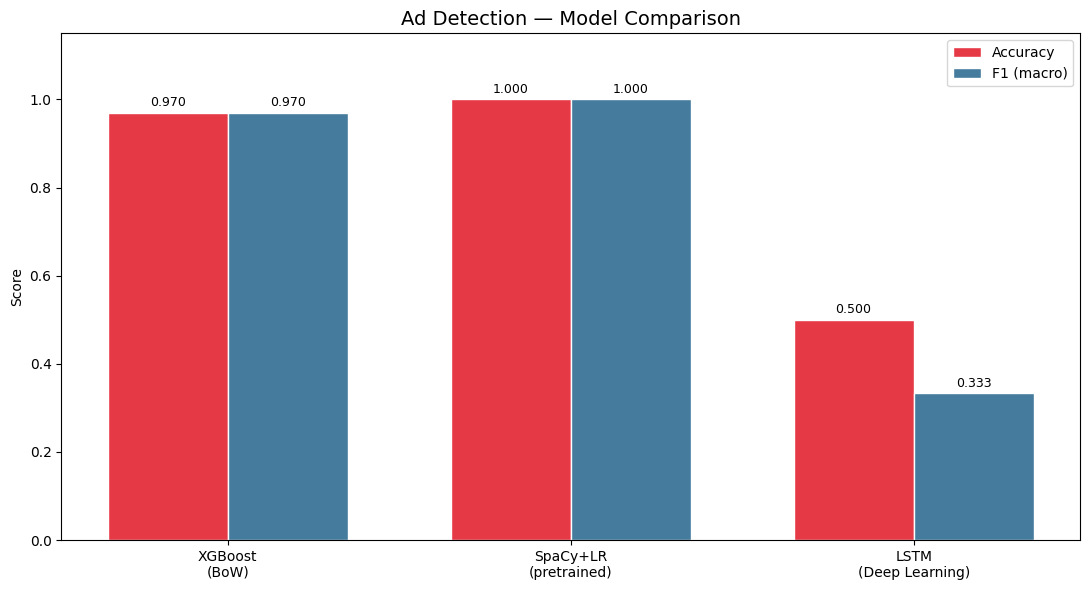

In [35]:
results = {
    'XGBoost\n(BoW)':           {'Accuracy': xgb_acc,
                                  'F1 (macro)': f1_score(y_test,    y_pred_xgb, average='macro')},
    'SpaCy+LR\n(pretrained)':   {'Accuracy': spacy_acc,
                                  'F1 (macro)': f1_score(y_test,    y_pred_sp,  average='macro')},
    'LSTM\n(Deep Learning)':    {'Accuracy': dl_acc,
                                  'F1 (macro)': f1_score(y_te_dl,   y_pred_dl,  average='macro')},
    # 'H2O\nAutoML':              {'Accuracy': h2o_acc, 'F1 (macro)': h2o_acc},
}
res_df = pd.DataFrame(results).T
print(res_df.round(4).to_string())

fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(res_df)); w = 0.35
b1 = ax.bar(x - w/2, res_df['Accuracy'],   w, label='Accuracy',   color='#E63946', edgecolor='white')
b2 = ax.bar(x + w/2, res_df['F1 (macro)'], w, label='F1 (macro)', color='#457B9D', edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(res_df.index, fontsize=10)
ax.set_ylim(0, 1.15); ax.set_ylabel('Score'); ax.legend()
ax.set_title('Ad Detection — Model Comparison', fontsize=14)
for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.015,
            f'{bar.get_height():.3f}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


## Summary

| Model | Features | Highlights |
|---|---|---|
| **XGBoost** | BoW unigrams+bigrams | Fast, feature importance reveals ad keywords |
| **SpaCy** | 300d pretrained GloVe | Semantic transfer — ad/promo words cluster together |
| **LSTM** | Learned embeddings | Sequential context — detects promotional sentence patterns |
| **H2O AutoML** | TF-IDF | Automated model search + stacked ensembles |

**Key observations for ad detection:**
- URLs are a strong ad signal (present in ~50% of dataset)
- Emoji demojization helps capture promotional patterns (🔥 → fire, 🛍️ → shopping bags)
- Hashtag text carries signal — #deals #sale #offer cluster in ad class
- Classical models (XGBoost on BoW) often competitive with deep learning on this task
